# Неделя 1. Анализ данных и токенизатор

ADL Piano MIDI: ~11 000 фортепианных MIDI по жанрам. Здесь:
1. сводка по датасету (жанры, длины, темпы, тональности, плотность нот);
2. пример: MIDI → REMI-токены → восстановленный MIDI.

Перед запуском: `python scripts/analyze_dataset.py` и `python scripts/eda.py`.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
import pandas as pd, numpy as np
from IPython.display import Image, Markdown, display
df = pd.read_csv(ROOT / 'data/processed/pieces.csv', keep_default_na=False, low_memory=False)
kept = df[df.reject == ''].copy()
for c in ['bpm', 'n_bars', 'notes_per_bar', 'n_tokens']:
    kept[c] = pd.to_numeric(kept[c])
print(f'файлов: {len(df)}, принято: {len(kept)}')
kept.groupby('genre').agg(пьес=('path', 'size'), исполнителей=('artist', 'nunique'))

файлов: 11087, принято: 8091


,пьес,исполнителей
genre,,
classical,617,171
country_folk,302,175
jazz,759,425
latin_world,563,292
pop,930,576
rock,2567,1429
soundtrack,814,343
unknown,1539,1189


## Графики (создаются `scripts/eda.py`)

**01_genres**

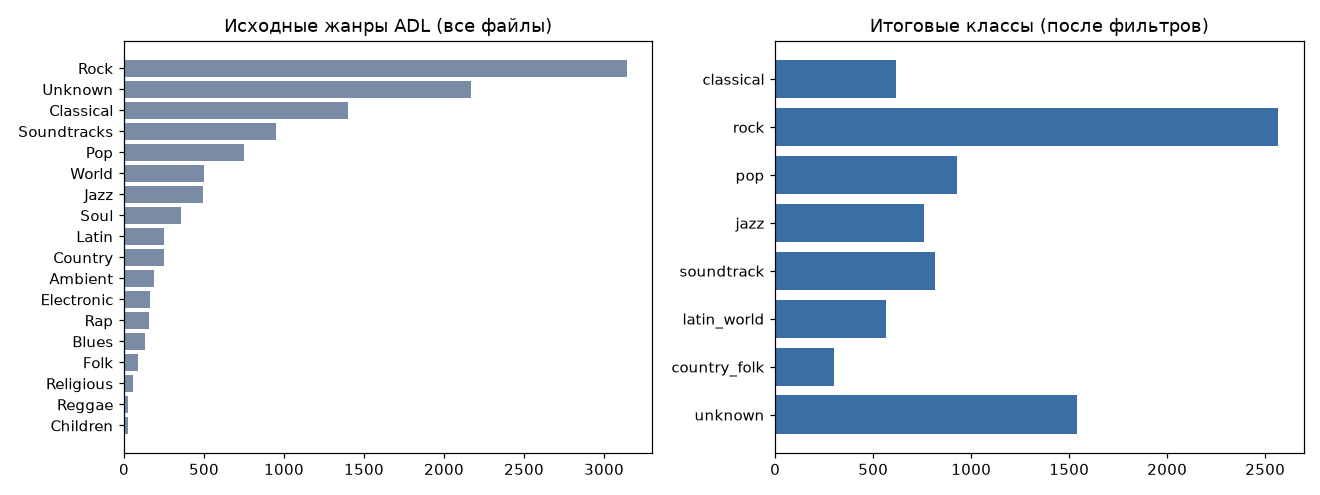

**02_filtering**

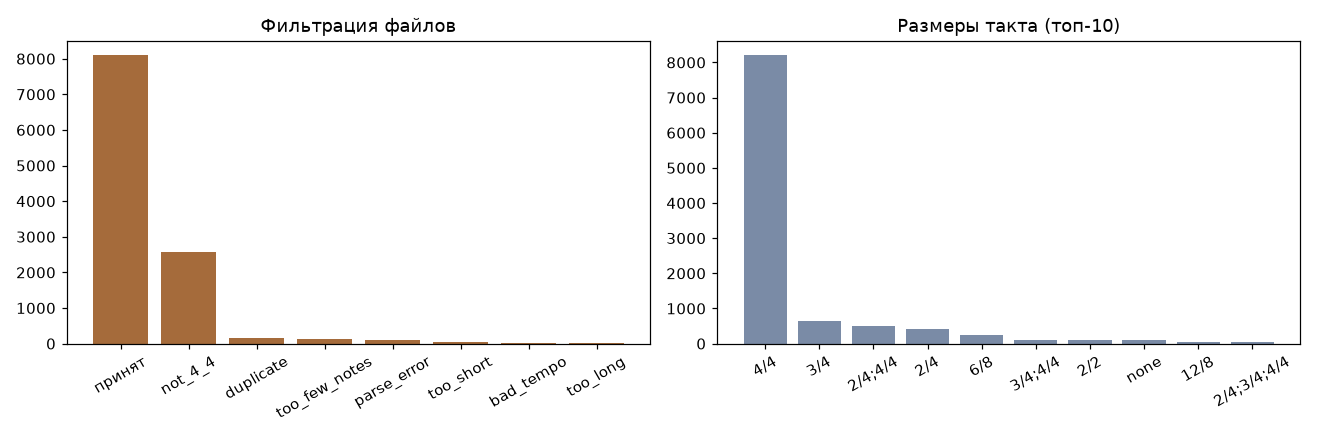

**03_length_tempo_density**

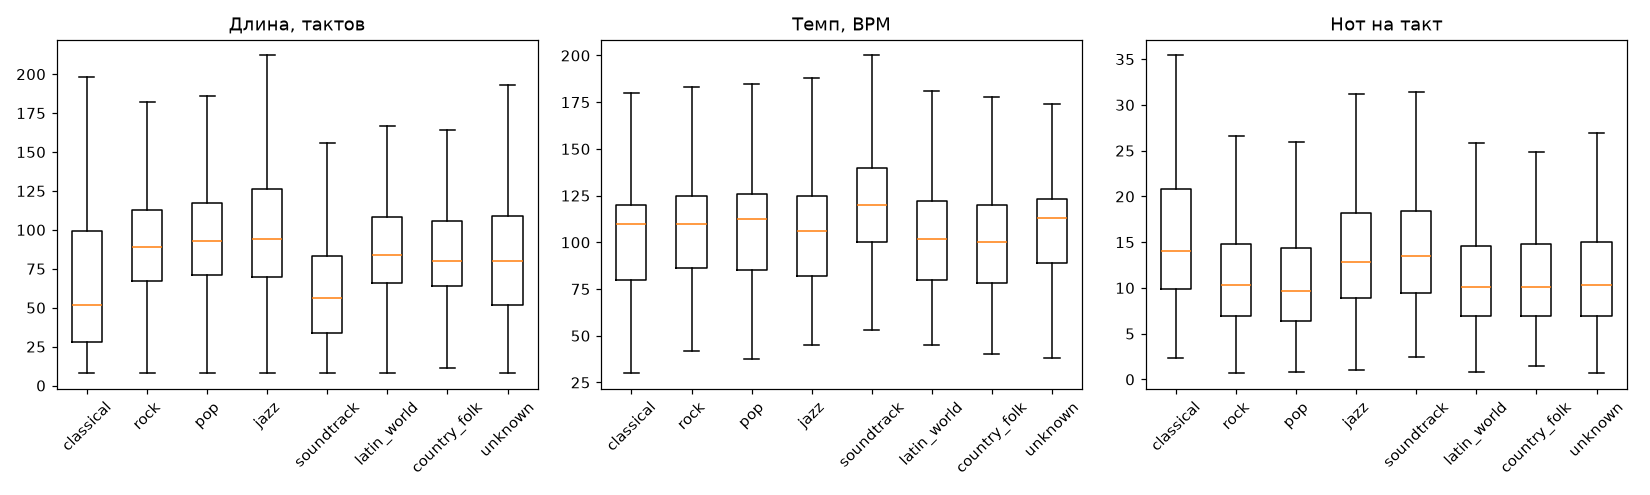

**04_tempo_length_hist**

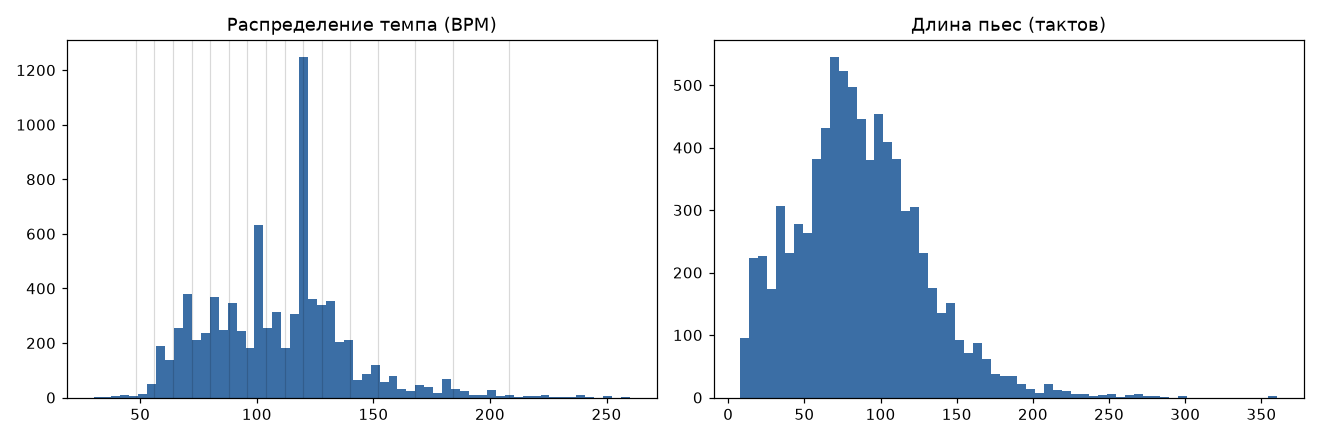

**05_keys**

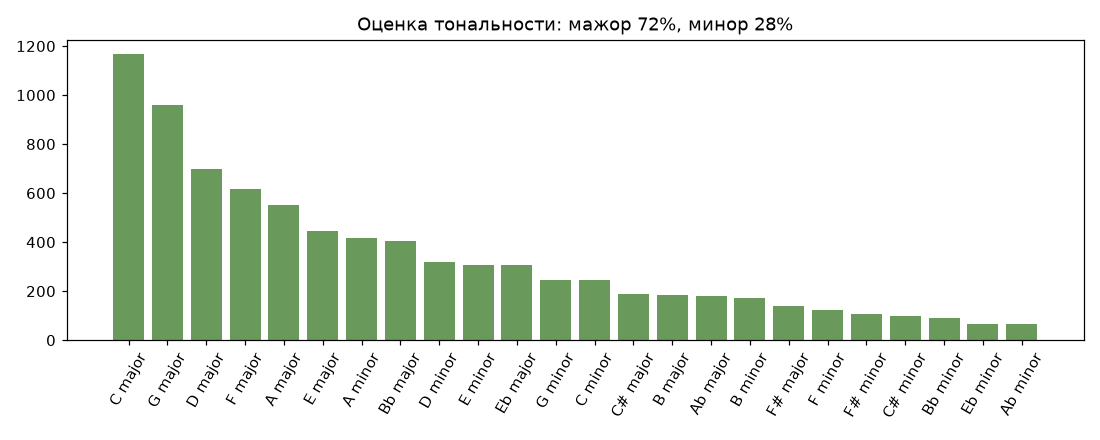

**06_tokens**

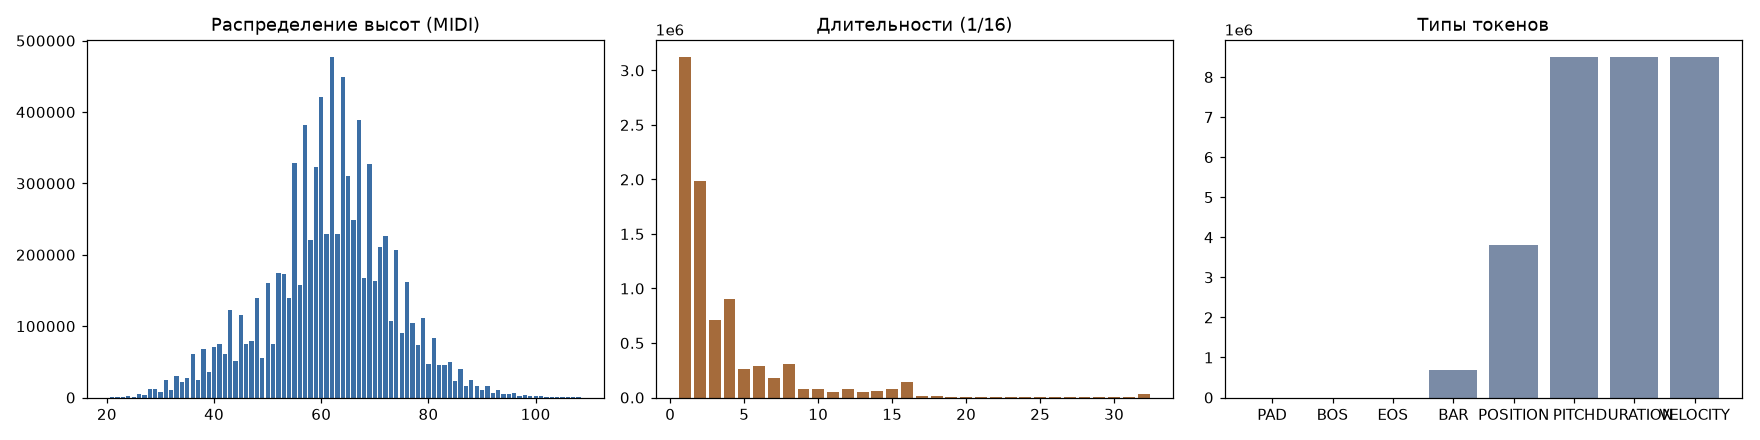

**07_sequence_length**

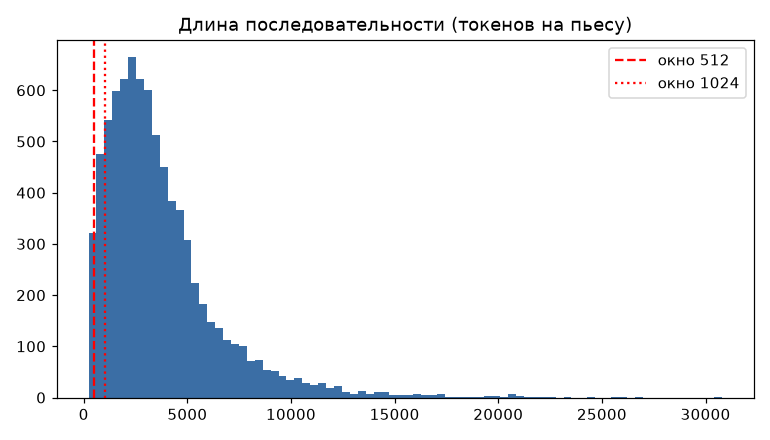

In [2]:
for f in sorted((ROOT / 'reports/figures').glob('*.png')):
    display(Markdown(f'**{f.stem}**')); display(Image(filename=str(f)))

## Медианы по жанрам

In [3]:
kept.groupby('genre')[['n_bars', 'bpm', 'notes_per_bar', 'n_tokens']].median().round(1)

,n_bars,bpm,notes_per_bar,n_tokens
genre,,,,
classical,52.0,110.0,14.0,2692.0
country_folk,80.0,100.0,10.1,2992.0
jazz,94.0,106.0,12.8,4210.0
latin_world,84.0,102.0,10.1,2947.0
pop,93.0,112.5,9.7,2984.0
rock,89.0,110.0,10.3,3151.0
soundtrack,56.0,120.0,13.5,2568.5
unknown,80.0,113.0,10.4,2742.0


## MIDI → токены → MIDI

Берём случайную пьесу, токенизируем, восстанавливаем и сравниваем ноты (с точностью до сетки 1/16 и бина громкости).

In [4]:
import zipfile
from musicgen.data.tokenizer import REMITokenizer, read_midi
from musicgen.data.vocab import Vocab
vocab = Vocab.load(ROOT / 'data/processed/vocab.json')
tok = REMITokenizer(vocab)
row = kept[kept.genre == 'jazz'].sample(1, random_state=0).iloc[0]
data = zipfile.ZipFile(ROOT / 'data/raw/adl-piano-midi.zip').read(row.path)
piece = read_midi(data)
tokens = tok.encode_piece(piece, row.genre)
print(row.artist, '—', row.title, f'| {piece.bpm} BPM, {piece.n_bars} тактов, {len(piece.notes)} нот, {len(tokens)} токенов')
print(' '.join(vocab.to_str(tokens[:40])))

Glenn Miller — Moonlight serenade | 84.0 BPM, 65 тактов, 627 нот, 2130 токенов
BOS GENRE_jazz TEMPO_88 LENGTH_64 BAR POSITION_0 PITCH_55 DURATION_15 VELOCITY_8 PITCH_58 DURATION_15 VELOCITY_8 PITCH_60 DURATION_15 VELOCITY_8 PITCH_63 DURATION_15 VELOCITY_8 POSITION_15 PITCH_51 DURATION_17 VELOCITY_8 PITCH_54 DURATION_17 VELOCITY_8 PITCH_57 DURATION_17 VELOCITY_8 PITCH_60 DURATION_17 VELOCITY_8 BAR BAR POSITION_0 PITCH_51 DURATION_7 VELOCITY_8 PITCH_56 DURATION_7 VELOCITY_8


In [5]:
notes, info = tok.decode(tokens)
q = lambda ns: {(n.start, n.pitch, n.duration, n.velocity // 8) for n in ns}
print('совпадение нот:', q(notes) == q(piece.notes), '| условия из префикса:', info)
out = ROOT / 'samples/week_1'
out.mkdir(parents=True, exist_ok=True)
(out / 'original.mid').write_bytes(data)
tok.decode_to_midi(tokens, out / 'reconstructed.mid', bpm=piece.bpm)
print('сохранено в', out)

совпадение нот: True | условия из префикса: {'genre': 'jazz', 'bpm': 88, 'n_bars': 64, 'n_bars_decoded': 65}
сохранено в D:\ai-music-gen\ai-music-gen\samples\week_1


Послушать: открыть `original.mid` и `reconstructed.mid` в любом MIDI-плеере / DAW (MuseScore, GarageBand, онлайн-плеер) и сравнить.